In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
phonepe = pd.read_excel("data/PhonePe_Digital_Payments.xlsx", sheet_name=None)

/opt/pyvenv/lib/python3.13/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


In [3]:
state_txn_and_users = phonepe["State_Txn and Users"]
state_txnsplit = phonepe["State_TxnSplit"]
state_devicedata = phonepe["State_DeviceData"]
district_txn_and_users = phonepe["District_Txn and Users"]
district_demographics = phonepe["District Demographics"]

# Task 1: Data Loading and Understanding

### 1.1: Lead each dataset and display Ite structure

In [4]:
# 1.⁠ ⁠Load the State-Tn and Users dataset and display ite first rows
state_txn_and_users.head(1)

,State,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
0,Andaman & Nicobar Islands,2018,1,6658,1.463176e+07,2197.621091,6740,0


In [5]:
# 2.⁠ ⁠Load the State-TnSpllt dataset and display its bottem 10 rows,
state_txnsplit.tail(10)

,State,Year,Quarter,Transaction Type,Transactions,Amount (INR),ATV (INR)
2504,West Bengal,2021,1,Peer-to-peer payments,53869075,2.022402e+11,3754.292226
2505,West Bengal,2021,1,Merchant payments,37143701,2.891834e+10,778.553104
2506,West Bengal,2021,1,Recharge & bill payments,26673733,1.133967e+10,425.124820
2507,West Bengal,2021,1,Financial Services,166727,1.754458e+08,1052.293941
2508,West Bengal,2021,1,Others,400816,2.635025e+08,657.415236
2509,West Bengal,2021,2,Peer-to-peer payments,64661051,2.308123e+11,3569.572026
2510,West Bengal,2021,2,Merchant payments,41696787,3.478787e+10,834.305703
2511,West Bengal,2021,2,Recharge & bill payments,34799709,1.333145e+10,383.090958
2512,West Bengal,2021,2,Financial Services,190537,1.864665e+08,978.636630
2513,West Bengal,2021,2,Others,549353,3.167447e+08,576.577748


In [6]:
# 3.⁠ ⁠Load the State_DeviceData dataset and display 10 rows from the middle of the dataset.
mid = len(state_devicedata) // 2
print(state_devicedata.iloc[mid-5:mid+5])

            State  Year  Quarter     Brand  Registered Users  Percentage
2767       Ladakh  2021        2   OnePlus              1741    0.023198
2768       Ladakh  2021        2  Motorola               922    0.012285
2769       Ladakh  2021        2    Huawei               894    0.011912
2770       Ladakh  2021        2    Lenovo               490    0.006529
2771       Ladakh  2021        2    Others              2610    0.034778
2772  Lakshadweep  2018        1   Samsung               102    0.203593
2773  Lakshadweep  2018        1    Xiaomi               100    0.199601
2774  Lakshadweep  2018        1      Vivo                67    0.133733
2775  Lakshadweep  2018        1      Oppo                56    0.111776
2776  Lakshadweep  2018        1    Huawei                25    0.049900


In [7]:
# 4.⁠ ⁠Load the District_Txn and Users dataset and display Its first 10 rows and last
district_txn_and_users.head(10)

,State,Year,Quarter,District,Code,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
0,Andaman & Nicobar Islands,2018,1,Nicobars,AN01,528,1.139849e+06,2158.804548,262,0
1,Andaman & Nicobar Islands,2018,1,North And Middle Andaman,AN02,442,9.316631e+05,2107.835016,632,0
2,Andaman & Nicobar Islands,2018,1,South Andaman,AN03,5688,1.256025e+07,2208.201361,5846,0
3,Andaman & Nicobar Islands,2018,2,Nicobars,AN01,1120,3.072437e+06,2743.247239,351,0
4,Andaman & Nicobar Islands,2018,2,North And Middle Andaman,AN02,825,1.317863e+06,1597.409798,911,0
5,Andaman & Nicobar Islands,2018,2,South Andaman,AN03,9395,2.394824e+07,2549.040502,8143,0
6,Andaman & Nicobar Islands,2018,3,Nicobars,AN01,1471,6.387829e+06,4342.507921,467,0
7,Andaman & Nicobar Islands,2018,3,North And Middle Andaman,AN02,1283,4.901530e+06,3820.365954,1208,0
8,Andaman & Nicobar Islands,2018,3,South Andaman,AN03,13511,4.426811e+07,3276.449742,10474,0
9,Andaman & Nicobar Islands,2018,4,Nicobars,AN01,1485,7.180859e+06,4835.595525,536,0


In [8]:
#4.2 District_Txn and Users dataset and display Its last 10 rows
district_txn_and_users.tail(10)

,State,Year,Quarter,District,Code,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
10238,West Bengal,2021,2,Murshidabad,WB14,8602251,1.999694e+10,2324.616616,1248602,16530655
10239,West Bengal,2021,2,Nadia,WB15,5524174,1.122758e+10,2032.445525,955428,13665885
10240,West Bengal,2021,2,North Twenty Four Parganas,WB16,17258291,3.041482e+10,1762.331031,2660664,37899453
10241,West Bengal,2021,2,Paschim Bardhaman,WB17,4893774,8.731263e+09,1784.157359,789026,10545670
10242,West Bengal,2021,2,Paschim Medinipur,WB18,5051834,1.030351e+10,2039.558976,856640,16201033
10243,West Bengal,2021,2,Purba Bardhaman,WB19,3920729,7.572502e+09,1931.401639,787970,12128849
10244,West Bengal,2021,2,Purba Medinipur,WB20,6418522,1.515507e+10,2361.146027,946277,15491958
10245,West Bengal,2021,2,Purulia,WB21,1895981,2.790996e+09,1472.059252,435131,8843358
10246,West Bengal,2021,2,South Twenty Four Parganas,WB22,6661813,1.339853e+10,2011.243709,1286588,19344293
10247,West Bengal,2021,2,Uttar Dinajpur,WB23,2253385,5.564221e+09,2469.272118,392388,8184990


In [9]:
# 5.⁠ ⁠Load the District Demographics dataset and display every 10th row.
district_demographics.iloc[::10]

,State,District,Headquarters,Population,Area (sq km),Density,Code,Alternate Name
0,Andhra Pradesh,Anantapur,Anantapur,4083315,19130.0,213,AP01,Anantapur
10,Andhra Pradesh,Visakhapatnam,Visakhapatnam,4288113,11161.0,384,AP10,Visakhapatnam
20,Arunachal Pradesh,Lepa Rada,Basar,0,0.0,0,AR08,Lepa Rada
30,Arunachal Pradesh,Siang,Pangin,31920,2919.0,11,AR18,Siang
40,Assam,Barpeta,Barpeta,1693622,3245.0,520,AS03,Barpeta
...,...,...,...,...,...,...,...,...
700,Chandigarh,Chandigarh,Chandigarh,1055450,114.0,9258,CH01,Chandigarh
710,Jammu & Kashmir,Jammu,Jammu,1526406,3097.0,596,JK07,Jammu
720,Jammu & Kashmir,Samba,Samba,318611,913.0,318,JK17,Samba
730,Delhi,North Delhi,Sadar Bazaar,887978,59.0,14557,DL04,North


In [10]:
state_txn_and_users.describe()

,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
count,504.000000,504.000000,5.040000e+02,5.030000e+02,504.000000,5.040000e+02,5.040000e+02
mean,2019.285714,2.357143,4.074000e+07,7.083332e+10,1993.471543,4.777501e+06,9.774471e+07
std,1.031181,1.109971,8.228714e+07,1.440902e+11,607.464894,6.644496e+06,2.042376e+08
min,2018.000000,1.000000,7.780000e+02,1.928611e+06,0.000000,5.010000e+02,0.000000e+00
25%,2018.000000,1.000000,5.925578e+05,1.167157e+09,1598.910667,1.574202e+05,0.000000e+00
50%,2019.000000,2.000000,6.217487e+06,1.051605e+10,1861.380589,1.747914e+06,2.930574e+06
75%,2020.000000,3.000000,4.363675e+07,6.947045e+10,2259.087924,7.320945e+06,8.615022e+07
max,2021.000000,4.000000,5.736165e+08,1.027958e+12,3938.733850,3.966470e+07,1.208084e+09


In [11]:
state_txn_and_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 504 entries, 0 to 503
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   State             504 non-null    object 
 1   Year              504 non-null    int64  
 2   Quarter           504 non-null    int64  
 3   Transactions      504 non-null    int64  
 4   Amount (INR)      503 non-null    float64
 5   ATV (INR)         504 non-null    float64
 6   Registered Users  504 non-null    int64  
 7   App Opens         504 non-null    int64  
dtypes: float64(2), int64(5), object(1)
memory usage: 31.6+ KB


## 1.2: Display basic statistics and data types for each dataset

In [12]:
datasets = {
    "State_Txn and Users": state_txn_and_users,
    "State_TxnSplit": state_txnsplit,
    "State_DeviceData": state_devicedata,
    "District_Txn and Users": district_txn_and_users,
    "District Demographics": district_demographics
}

for name, df in datasets.items():
    print("\n" + "="*60)
    print(name)
    print("="*60)

    print("\nData Types:")
    print(df.dtypes)

    print("\nSummary Statistics:")
    print(df.describe())


State_Txn and Users

Data Types:
State                object
Year                  int64
Quarter               int64
Transactions          int64
Amount (INR)        float64
ATV (INR)           float64
Registered Users      int64
App Opens             int64
dtype: object

Summary Statistics:
              Year     Quarter  ...  Registered Users     App Opens
count   504.000000  504.000000  ...      5.040000e+02  5.040000e+02
mean   2019.285714    2.357143  ...      4.777501e+06  9.774471e+07
std       1.031181    1.109971  ...      6.644496e+06  2.042376e+08
min    2018.000000    1.000000  ...      5.010000e+02  0.000000e+00
25%    2018.000000    1.000000  ...      1.574202e+05  0.000000e+00
50%    2019.000000    2.000000  ...      1.747914e+06  2.930574e+06
75%    2020.000000    3.000000  ...      7.320945e+06  8.615022e+07
max    2021.000000    4.000000  ...      3.966470e+07  1.208084e+09

[8 rows x 7 columns]

State_TxnSplit

Data Types:
State                object
Year            

# 1.3: Check for missing values

In [13]:
state_txn_and_users.isnull().sum()

State               0
Year                0
Quarter             0
Transactions        0
Amount (INR)        1
ATV (INR)           0
Registered Users    0
App Opens           0
dtype: int64

## 1.3: Check for missing values

In [14]:
for name, df in datasets.items():

    print("\n" + "="*60)
    print(name)
    print("="*60)

    missing = df.isna().sum()
    missing_pct = (df.isna().mean() * 100).round(2)

    missing_report = pd.DataFrame({
        "Missing Count": missing,
        "Missing Percentage": missing_pct
    })

    print(missing_report[missing_report["Missing Count"] > 0])

    if missing.sum() > 0:
        highest_missing_column = missing_pct.idxmax()
        print(
            "\nHighest missing percentage:",
            highest_missing_column,
            missing_pct[highest_missing_column], "%"
        )
    else:
        print("\nNo missing values found.")


State_Txn and Users
              Missing Count  Missing Percentage
Amount (INR)              1                 0.2

Highest missing percentage: Amount (INR) 0.2 %

State_TxnSplit
Empty DataFrame
Columns: [Missing Count, Missing Percentage]
Index: []

No missing values found.

State_DeviceData
Empty DataFrame
Columns: [Missing Count, Missing Percentage]
Index: []

No missing values found.

District_Txn and Users
           Missing Count  Missing Percentage
Code                  28                0.27
ATV (INR)              4                0.04

Highest missing percentage: Code 0.27 %

District Demographics
Empty DataFrame
Columns: [Missing Count, Missing Percentage]
Index: []

No missing values found.


## 1.4: Create a summary

In [15]:
# 1.⁠ ⁠Calculate the total number of states and the total number of districts.
total_state = state_txn_and_users["State"].nunique()
print("Total State:", total_state)

Total State: 36


In [16]:
district_demographics["District"].nunique()

736

# Task 2: Exploratory Data Analysis (EDA)

## 2.1: Analyze transaction trends over the years for each state

### 1.⁠ ⁠Calculate the total number of transactions and total transaction amount for each state over the years. Display the results in a tabular format

In [17]:
transaction_trend = state_txn_and_users.groupby(["State","Year"],as_index = False).agg(Total_Transaction = ("Transactions","sum"),
                                        Total_Transaction_Amount_INR = ("Amount (INR)","sum")).sort_values(["State","Year"])

In [18]:
transaction_trend.head()

,State,Year,Total_Transaction,Total_Transaction_Amount_INR
0,Andaman & Nicobar Islands,2018,58021,1.890761e+08
1,Andaman & Nicobar Islands,2019,133104,4.734648e+08
2,Andaman & Nicobar Islands,2020,446274,1.296423e+09
3,Andaman & Nicobar Islands,2021,586166,1.682854e+09
4,Andhra Pradesh,2018,77779112,1.220720e+11


### 2.⁠ ⁠Identify the top 5 states with the highest transaction volumes and the top 5 states with the lowest transaction volumes Display the results.

In [19]:
transaction_volumes = state_txn_and_users.groupby("State")["Transactions"].sum()

In [20]:
Top_5_states = transaction_volumes.sort_values(ascending = False).head()

In [21]:
Top_5_states

State
Karnataka         2981044533
Maharashtra       2833670154
Telangana         2347430243
Andhra Pradesh    1781091169
Rajasthan         1382918930
Name: Transactions, dtype: int64

In [22]:
bottom_5_states = transaction_volumes.sort_values().head()

In [23]:
bottom_5_states

State
Lakshadweep                    71610
Andaman & Nicobar Islands    1223565
Ladakh                       1880109
Mizoram                      2162776
Meghalaya                    5648913
Name: Transactions, dtype: int64

## 2.2: Identify the most common transaction types in each state and quarter

### 1. For each state and quarter, determine the most frequent transaction type.Display the results in a tabular format.

In [24]:
most_frequent_transaction_type = state_txnsplit.sort_values("Transactions",ascending = False).drop_duplicates(["State","Year","Quarter"]).sort_values(["State","Year","Quarter"])


In [25]:
most_frequent_transaction_type

,State,Year,Quarter,Transaction Type,Transactions,Amount (INR),ATV (INR)
0,Andaman & Nicobar Islands,2018,1,Recharge & bill payments,4200,1.845307e+06,439.358921
5,Andaman & Nicobar Islands,2018,2,Recharge & bill payments,6735,2.320945e+06,344.609463
10,Andaman & Nicobar Islands,2018,3,Recharge & bill payments,8636,4.343505e+06,502.953320
15,Andaman & Nicobar Islands,2018,4,Recharge & bill payments,11517,5.450550e+06,473.261224
20,Andaman & Nicobar Islands,2019,1,Recharge & bill payments,15263,6.611460e+06,433.169093
...,...,...,...,...,...,...,...
2489,West Bengal,2020,2,Peer-to-peer payments,24855687,8.498400e+10,3419.096979
2494,West Bengal,2020,3,Peer-to-peer payments,37556349,1.331207e+11,3544.558502
2499,West Bengal,2020,4,Peer-to-peer payments,46437233,1.663919e+11,3583.156529
2504,West Bengal,2021,1,Peer-to-peer payments,53869075,2.022402e+11,3754.292226


In [26]:
 most_frequent_transaction_type[["State", "Year", "Quarter", "Transaction Type", "Transactions"]].head(10)

,State,Year,Quarter,Transaction Type,Transactions
0,Andaman & Nicobar Islands,2018,1,Recharge & bill payments,4200
5,Andaman & Nicobar Islands,2018,2,Recharge & bill payments,6735
10,Andaman & Nicobar Islands,2018,3,Recharge & bill payments,8636
15,Andaman & Nicobar Islands,2018,4,Recharge & bill payments,11517
20,Andaman & Nicobar Islands,2019,1,Recharge & bill payments,15263
25,Andaman & Nicobar Islands,2019,2,Recharge & bill payments,14676
30,Andaman & Nicobar Islands,2019,3,Recharge & bill payments,16219
35,Andaman & Nicobar Islands,2019,4,Peer-to-peer payments,18128
40,Andaman & Nicobar Islands,2020,1,Peer-to-peer payments,18324
45,Andaman & Nicobar Islands,2020,2,Recharge & bill payments,38125


## 2.3: Determine the device brand with the highest number of registered users in each state

### 1.⁠ ⁠Identify the device brand with the highest number of registered users in each state. Display the results in a tabular format

In [27]:
Registered_users = state_devicedata.sort_values("Registered Users",ascending = False).drop_duplicates("State").sort_values("State")

In [28]:
Registered_users[["State","Brand","Registered Users"]]

,State,Brand,Registered Users
143,Andaman & Nicobar Islands,Vivo,15056
297,Andhra Pradesh,Xiaomi,4937684
451,Arunachal Pradesh,Vivo,63439
605,Assam,Xiaomi,909274
759,Bihar,Xiaomi,4268361
913,Chandigarh,Xiaomi,101761
1067,Chhattisgarh,Vivo,1169224
1221,Dadra & Nagar Haveli and Daman & Diu,Vivo,87001
1375,Delhi,Xiaomi,2731995
1529,Goa,Xiaomi,152107


## 2.4: Create a list of the top district per state based on population

### 1.⁠ ⁠For each state, identify the district with the highest population. Display the results in a tabular format.

In [29]:
distric_highest_population = district_demographics.sort_values("Population",ascending = False).drop_duplicates("State").sort_values("State")

In [30]:
distric_highest_population[["State","District","Population"]]

,State,District,Population
699,Andaman & Nicobar Islands,South Andaman,238142
2,Andhra Pradesh,East Godavari,5151549
28,Arunachal Pradesh,Papum Pare,176385
64,Assam,Nagaon,2826006
97,Bihar,Patna,5772804
700,Chandigarh,Chandigarh,1055450
133,Chhattisgarh,Raipur,2160876
703,Dadra & Nagar Haveli and Daman & Diu,Dadra and Nagar Haveli,343709
732,Delhi,North West Delhi,3656539
138,Goa,North Goa,817761


### 2.⁠ ⁠Create a column chart depicting the district with the highest population for each state.

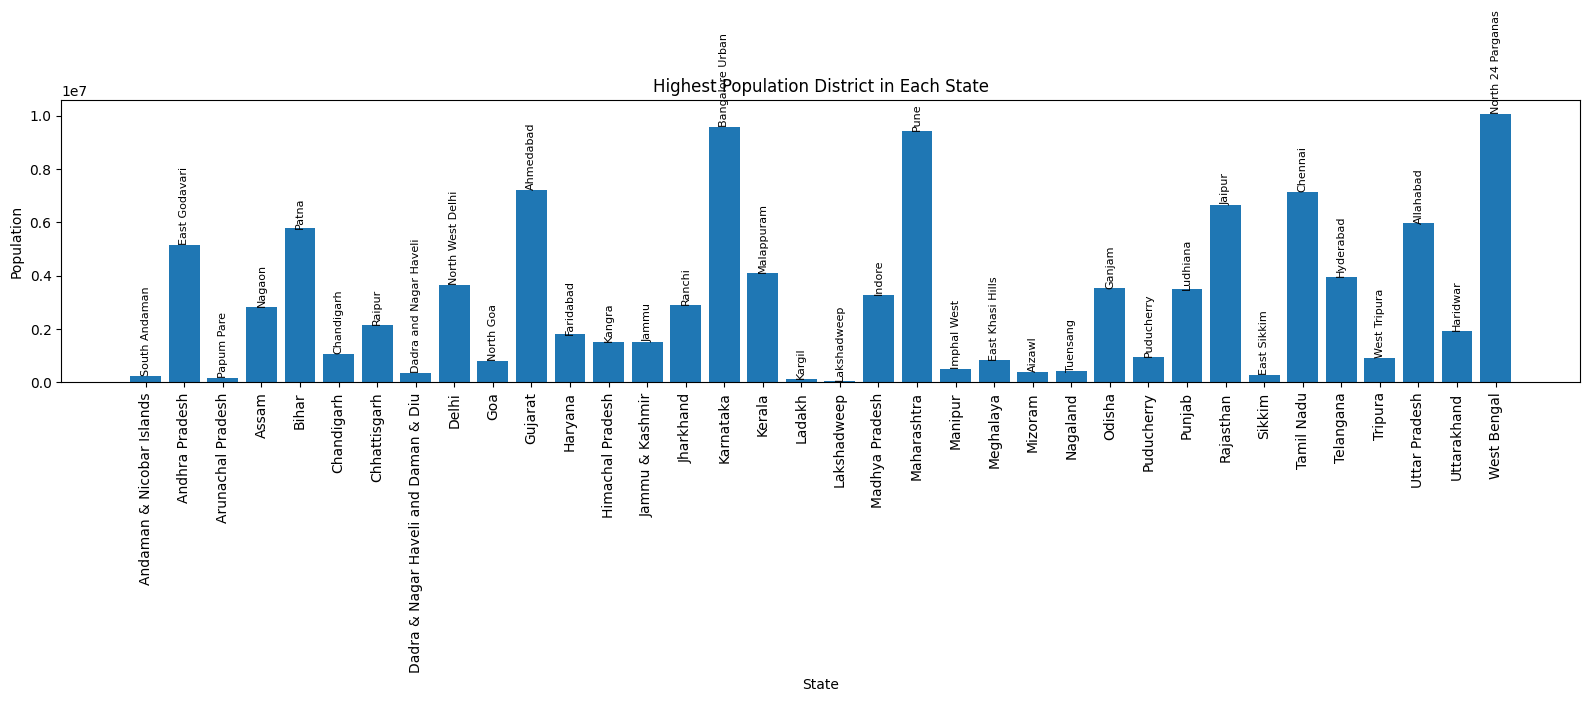

In [31]:
plt.figure(figsize=(16, 7))

bars = plt.bar(
    distric_highest_population["State"],
    distric_highest_population["Population"]
)

plt.xlabel("State")
plt.ylabel("Population")
plt.title("Highest Population District in Each State")

plt.xticks(rotation=90)

# Add district name above each bar
for bar, district in zip(
    bars,
    distric_highest_population["District"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        district,
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=8
    )

plt.tight_layout()
plt.show()

## 2.5: Calculate the average transaction value (ATV) for each state

### 1.⁠ ⁠Compute the average transaction value for each state. Display the results in a tabular format.

In [32]:
state_txn_and_users.head()

,State,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
0,Andaman & Nicobar Islands,2018,1,6658,1.463176e+07,2197.621091,6740,0
1,Andaman & Nicobar Islands,2018,2,11340,2.833854e+07,2498.989022,9405,0
2,Andaman & Nicobar Islands,2018,3,16265,5.555747e+07,3415.768284,12149,0
3,Andaman & Nicobar Islands,2018,4,23758,9.054834e+07,3811.277720,15222,0
4,Andaman & Nicobar Islands,2019,1,30486,1.022997e+08,3355.630147,18596,0


In [33]:
average_atv = state_txn_and_users.groupby("State")["ATV (INR)"].mean()

In [34]:
average_atv.head()

State
Andaman & Nicobar Islands    3159.266422
Andhra Pradesh               1748.091476
Arunachal Pradesh            2638.323985
Assam                        2008.495656
Bihar                        2023.316978
Name: ATV (INR), dtype: float64

### 2.⁠ ⁠Identify the top 5 states with the highest ATV and the top 5 states with the lowest ATV. Display the results.

In [35]:
top_5_ATV_state = average_atv.sort_values(ascending = False).head()
top_5_ATV_state

State
Ladakh                       3408.222984
Andaman & Nicobar Islands    3159.266422
Mizoram                      2927.517802
Lakshadweep                  2776.118701
Arunachal Pradesh            2638.323985
Name: ATV (INR), dtype: float64

In [36]:
bottom_5_ATV_state = average_atv.sort_values().head()
bottom_5_ATV_state

State
West Bengal                             1373.600590
Odisha                                  1428.137367
Dadra & Nagar Haveli and Daman & Diu    1487.395599
Maharashtra                             1516.361820
Karnataka                               1517.392249
Name: ATV (INR), dtype: float64

## 2.6: Analyze app usage trends

### 1.⁠ ⁠Calculate the total number of app opens over the years and quarters for each state. Display the results in a tabular format.

In [37]:
app_opens = state_txn_and_users.groupby(["State","Year","Quarter"])["App Opens"].sum().reset_index().sort_values(["State","Year","Quarter"])

In [38]:
app_opens.head(10)

,State,Year,Quarter,App Opens
0,Andaman & Nicobar Islands,2018,1,0
1,Andaman & Nicobar Islands,2018,2,0
2,Andaman & Nicobar Islands,2018,3,0
3,Andaman & Nicobar Islands,2018,4,0
4,Andaman & Nicobar Islands,2019,1,0
5,Andaman & Nicobar Islands,2019,2,52640
6,Andaman & Nicobar Islands,2019,3,171107
7,Andaman & Nicobar Islands,2019,4,177012
8,Andaman & Nicobar Islands,2020,1,193586
9,Andaman & Nicobar Islands,2020,2,305072


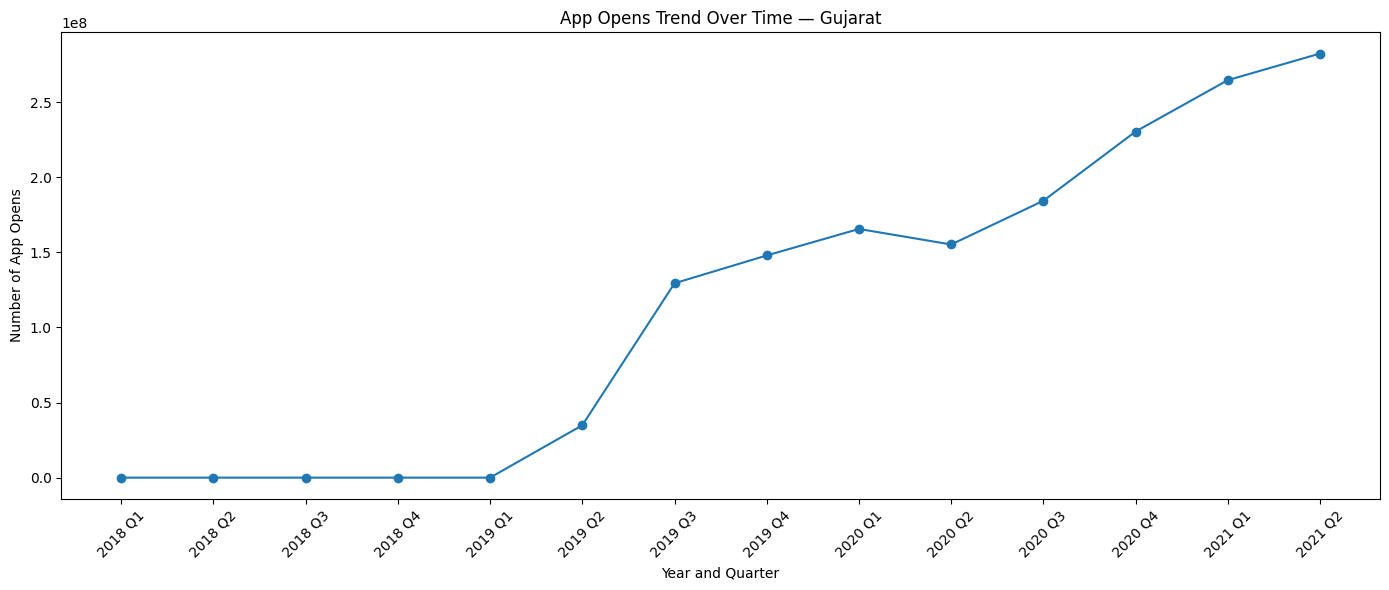

In [39]:
# Select a state
selected_state = "Gujarat"

# Filter data for the selected state
gujarat_app = (
    state_txn_and_users[
        state_txn_and_users["State"] == selected_state
    ]
    .sort_values(["Year", "Quarter"])
)

# Create a time label using Year and Quarter
gujarat_app["Time"] = (
    gujarat_app["Year"].astype(str)
    + " Q"
    + gujarat_app["Quarter"].astype(str)
)

# Line plot
plt.figure(figsize=(14, 6))

plt.plot(
    gujarat_app["Time"],
    gujarat_app["App Opens"],
    marker="o"
)

plt.xlabel("Year and Quarter")
plt.ylabel("Number of App Opens")
plt.title("App Opens Trend Over Time — Gujarat")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2.7: Distribution of transaction types

### 1.⁠ ⁠Create a bar chart showing the distribution of different transaction types for each state for the most recent quarter in the dataset.

In [40]:
latest_year = state_txnsplit["Year"].max()

latest_quarter = state_txnsplit[
    state_txnsplit["Year"] == latest_year
]["Quarter"].max()

In [41]:
latest_data = state_txnsplit[
    (state_txnsplit["Year"] == latest_year) &
    (state_txnsplit["Quarter"] == latest_quarter)
]

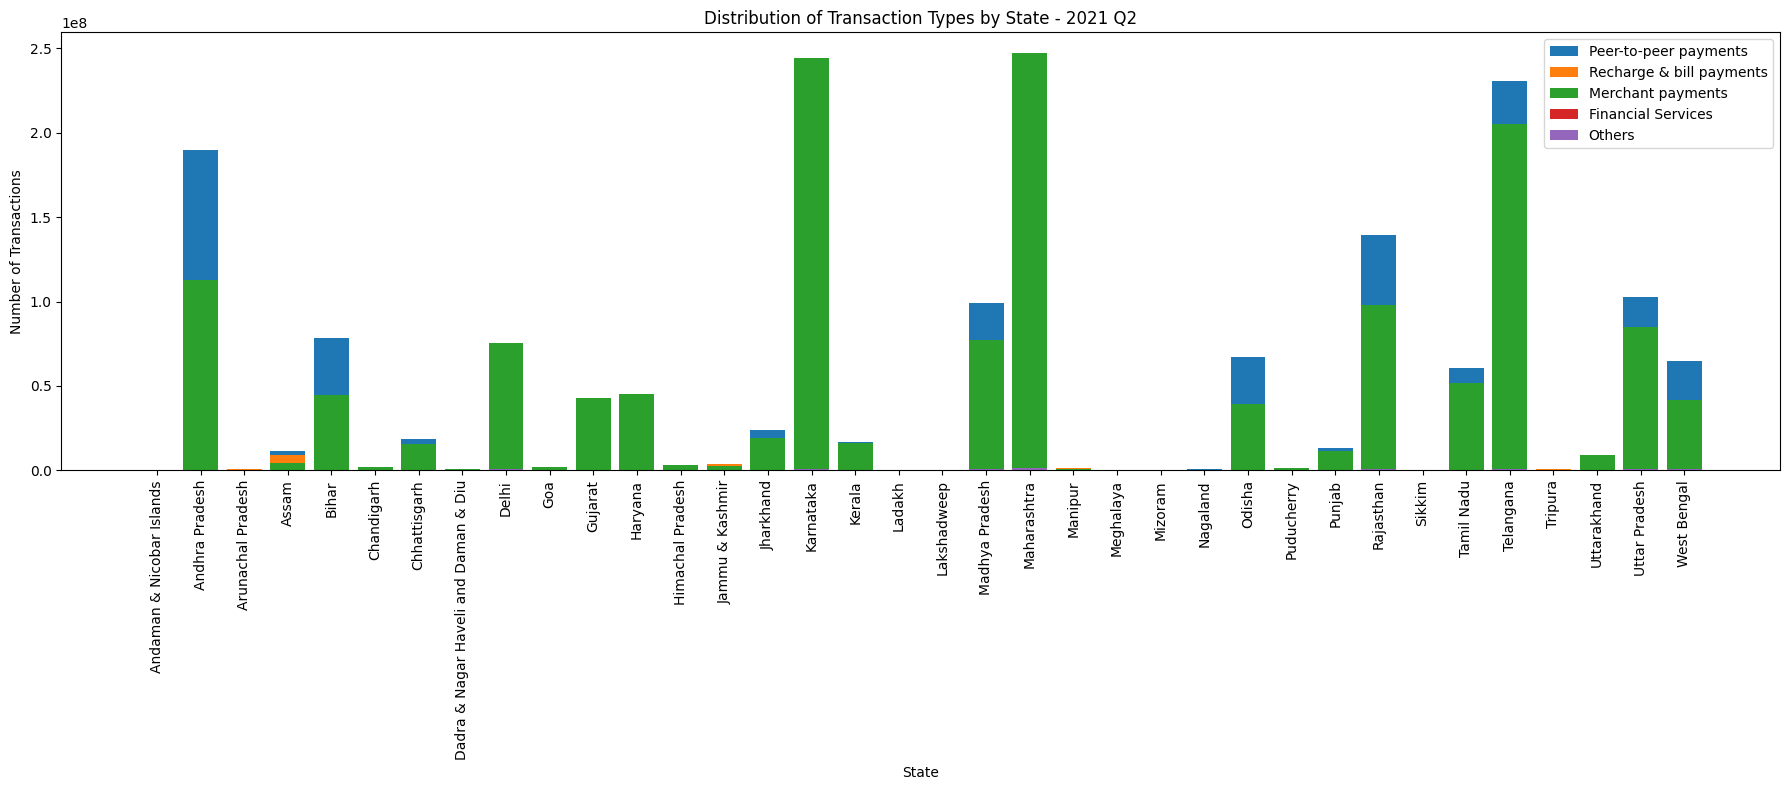

In [42]:
plt.figure(figsize=(18, 8))

for transaction_type in latest_data["Transaction Type"].unique():

    data = latest_data[
        latest_data["Transaction Type"] == transaction_type
    ]

    plt.bar(
        data["State"],
        data["Transactions"],
        label=transaction_type
    )

plt.xlabel("State")
plt.ylabel("Number of Transactions")
plt.title(
    f"Distribution of Transaction Types by State - "
    f"{latest_year} Q{latest_quarter}"
)

plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

## 2.8: Find unique mapping between district name and district code

### 1.⁠ ⁠Identify the unique mapping between district names and district codes from the dataset. [hint: you can use drop_duplicates)]

In [43]:
district_mapping = district_demographics[["District","Code"]].drop_duplicates()

In [44]:
district_mapping.head()

,District,Code
0,Anantapur,AP01
1,Chittoor,AP02
2,East Godavari,AP03
3,Guntur,AP04
4,YSR,AP13


### 2.⁠ ⁠Create a CSV file containing the unique district name and district code mappings.

In [45]:
district_mapping.to_csv("distict_name_code_mapping.csv",index = False)

# Task 3: Data Quality Checks

## 3.1: Ensure data consistency across state and district levels

### 1.⁠ ⁠For each state, calculate the total number of transactions, total transaction amount, and total registered users by summing up the values from the district level data.

In [46]:
district_txn_and_users.head()

,State,Year,Quarter,District,Code,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
0,Andaman & Nicobar Islands,2018,1,Nicobars,AN01,528,1.139849e+06,2158.804548,262,0
1,Andaman & Nicobar Islands,2018,1,North And Middle Andaman,AN02,442,9.316631e+05,2107.835016,632,0
2,Andaman & Nicobar Islands,2018,1,South Andaman,AN03,5688,1.256025e+07,2208.201361,5846,0
3,Andaman & Nicobar Islands,2018,2,Nicobars,AN01,1120,3.072437e+06,2743.247239,351,0
4,Andaman & Nicobar Islands,2018,2,North And Middle Andaman,AN02,825,1.317863e+06,1597.409798,911,0


In [47]:
state_for_district = district_txn_and_users.groupby("State")[["Transactions","Amount (INR)","Registered Users"]].sum()

In [48]:
state_for_district.tail()

,Transactions,Amount (INR),Registered Users
State,,,
Telangana,2347430243,4.574246e+12,149224214
Tripura,12018152,2.097051e+10,3661575
Uttar Pradesh,1314714390,2.399757e+12,246200404
Uttarakhand,124011162,2.150715e+11,23792747
West Bengal,942286041,1.452707e+12,144242183


### 2.⁠ ⁠Compare the results with the corresponding values at the state level to ensure they match.

In [49]:
state_txn_and_users.head()

,State,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
0,Andaman & Nicobar Islands,2018,1,6658,1.463176e+07,2197.621091,6740,0
1,Andaman & Nicobar Islands,2018,2,11340,2.833854e+07,2498.989022,9405,0
2,Andaman & Nicobar Islands,2018,3,16265,5.555747e+07,3415.768284,12149,0
3,Andaman & Nicobar Islands,2018,4,23758,9.054834e+07,3811.277720,15222,0
4,Andaman & Nicobar Islands,2019,1,30486,1.022997e+08,3355.630147,18596,0


In [50]:
state_level = state_txn_and_users.groupby("State")[["Transactions","Amount (INR)","Registered Users"]].sum()

In [51]:
state_level.tail()

,Transactions,Amount (INR),Registered Users
State,,,
Telangana,2347430243,4.574246e+12,149224214
Tripura,12018152,2.097051e+10,3661575
Uttar Pradesh,1314714390,2.399757e+12,246200404
Uttarakhand,124011162,2.150715e+11,23792747
West Bengal,942286041,1.452707e+12,144242183


In [52]:
comparison = state_level.merge(state_for_district,on="State",suffixes = ("_State","_District"))

In [53]:
comparison.tail()

,Transactions_State,Amount (INR)_State,Registered Users_State,Transactions_District,Amount (INR)_District,Registered Users_District
State,,,,,,
Telangana,2347430243,4.574246e+12,149224214,2347430243,4.574246e+12,149224214
Tripura,12018152,2.097051e+10,3661575,12018152,2.097051e+10,3661575
Uttar Pradesh,1314714390,2.399757e+12,246200404,1314714390,2.399757e+12,246200404
Uttarakhand,124011162,2.150715e+11,23792747,124011162,2.150715e+11,23792747
West Bengal,942286041,1.452707e+12,144242183,942286041,1.452707e+12,144242183


In [54]:
comparison["Transaction_Match"]=(comparison["Transactions_State"]==comparison["Transactions_District"])
comparison["Amount_Match"] = np.isclose(comparison["Amount (INR)_State"],comparison["Amount (INR)_District"],rtol=1e-12,atol=1)
comparison["Users_Match"]=(comparison["Registered Users_State"]==comparison["Registered Users_District"])

In [55]:
comparison

,Transactions_State,Amount (INR)_State,Registered Users_State,Transactions_District,Amount (INR)_District,Registered Users_District,Transaction_Match,Amount_Match,Users_Match
State,,,,,,,,,
Andaman & Nicobar Islands,1223565,3.641818e+09,408396,1223565,3.641818e+09,408396,True,True,True
Andhra Pradesh,1781091169,3.187847e+12,158007957,1781091169,3.860292e+12,158007957,True,False,True
Arunachal Pradesh,8043799,2.225183e+10,1862214,8043799,2.225183e+10,1862214,True,True,True
Assam,123577981,2.814087e+11,26860751,123577981,2.814087e+11,26860751,True,True,True
Bihar,713643889,1.639579e+12,115284760,713643889,1.639579e+12,115284760,True,True,True
Chandigarh,25516542,5.371208e+10,3801466,25516542,5.371208e+10,3801466,True,True,True
Chhattisgarh,241908549,4.156353e+11,37448388,241908549,4.156353e+11,37448388,True,True,True
Dadra & Nagar Haveli and Daman & Diu,12462185,1.865878e+10,2701112,12462185,1.865878e+10,2701112,True,True,True
Delhi,1011031124,1.649942e+12,95374654,1011031124,1.649942e+12,95374654,True,True,True


### 3.⁠ ⁠Display any discrepancies found between the district-level and state-level data.

In [56]:
discrepancies = comparison[(comparison["Transaction_Match"]== False)|(comparison["Amount_Match"]==False)| (comparison["Users_Match"]==False)]

In [57]:
discrepancies

,Transactions_State,Amount (INR)_State,Registered Users_State,Transactions_District,Amount (INR)_District,Registered Users_District,Transaction_Match,Amount_Match,Users_Match
State,,,,,,,,,
Andhra Pradesh,1781091169,3.187847e+12,158007957,1781091169,3.860292e+12,158007957,True,False,True


# Task 4: Data Merging and Advanced Analysis

## 4.1: Ratio of users to population by state

### 1.⁠ ⁠Merge the State_Txnand Users dataset with the District Demographics dataset to calculate the ratio of registered users to the population for each state.Display the results in a tabular format.

In [58]:
latest_year = state_txn_and_users["Year"].max()
latest_quarter = (state_txn_and_users[state_txn_and_users["Year"]==latest_year]["Quarter"].max())

In [59]:
latest_year

np.int64(2021)

In [60]:
registered_users = state_txn_and_users[(state_txn_and_users["Year"]==latest_year) & (state_txn_and_users["Quarter"]==latest_quarter)][["State","Registered Users"]]

In [61]:
registered_users.head()

,State,Registered Users
13,Andaman & Nicobar Islands,62095
27,Andhra Pradesh,19620905
41,Arunachal Pradesh,270572
55,Assam,3617056
69,Bihar,14972134


In [62]:
population = district_demographics.groupby("State")["Population"].sum().reset_index()

In [63]:
population.head()

,State,Population
0,Andaman & Nicobar Islands,380581
1,Andhra Pradesh,49378776
2,Arunachal Pradesh,1606047
3,Assam,34461385
4,Bihar,103817951


In [64]:
raio_merge = registered_users.merge(population,on="State")

In [65]:
raio_merge["Ratio(%)"] = (raio_merge["Registered Users"]/raio_merge["Population"])*100

In [66]:
raio_merge.head()

,State,Registered Users,Population,Ratio(%)
0,Andaman & Nicobar Islands,62095,380581,16.315843
1,Andhra Pradesh,19620905,49378776,39.735503
2,Arunachal Pradesh,270572,1606047,16.847079
3,Assam,3617056,34461385,10.495968
4,Bihar,14972134,103817951,14.421527


### 2.⁠ ⁠Create a column chart depicting the ratio of users to population by state

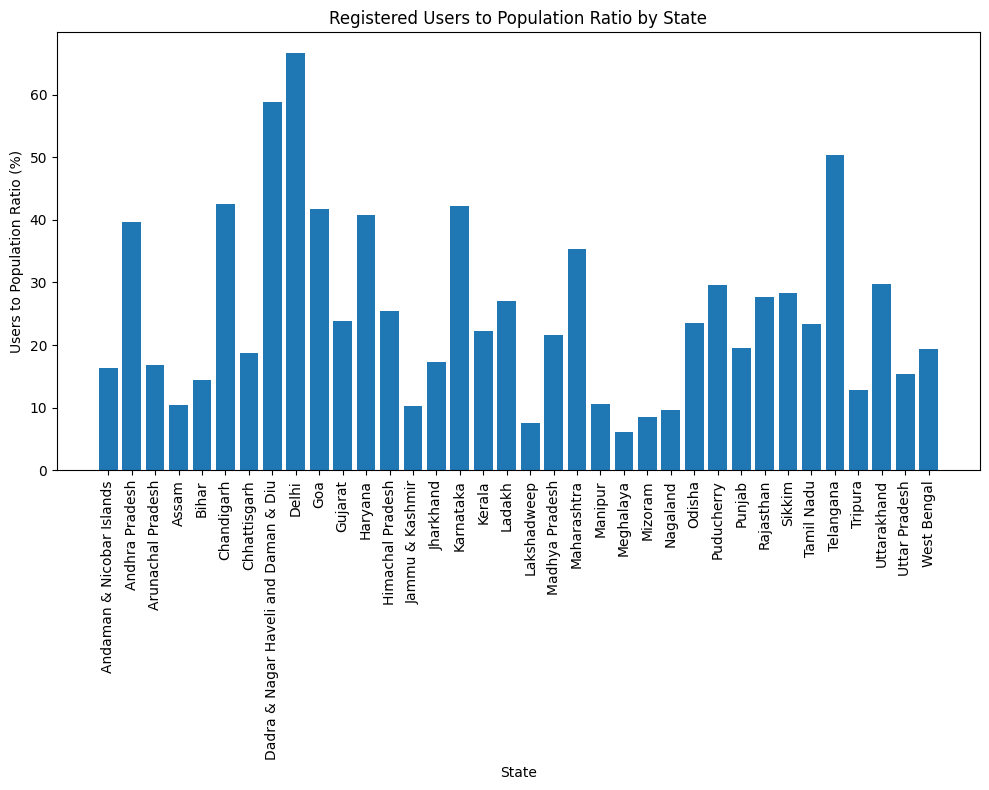

In [67]:
plt.figure(figsize = (10,8))

plt.bar(raio_merge["State"],raio_merge["Ratio(%)"])

plt.xlabel("State")
plt.ylabel("Users to Population Ratio (%)")
plt.title("Registered Users to Population Ratio by State")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

## 4.2: Correlate population density with transaction volume

### 1.⁠ ⁠Merge the District Txn and Users dataset with the District Demographics dataset.

In [68]:
district_merge = district_txn_and_users.merge(district_demographics,on=["State","Code"],how = "left")

In [69]:
district_merge.head()

,State,Year,Quarter,District_x,Code,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens,District_y,Headquarters,Population,Area (sq km),Density,Alternate Name
0,Andaman & Nicobar Islands,2018,1,Nicobars,AN01,528,1.139849e+06,2158.804548,262,0,Nicobar,Car Nicobar,36842.0,1841.0,20.0,Nicobars
1,Andaman & Nicobar Islands,2018,1,North And Middle Andaman,AN02,442,9.316631e+05,2107.835016,632,0,North and Middle Andaman,Mayabunder,105597.0,3736.0,28.0,North and Middle Andaman
2,Andaman & Nicobar Islands,2018,1,South Andaman,AN03,5688,1.256025e+07,2208.201361,5846,0,South Andaman,Port Blair,238142.0,2672.0,89.0,South Andaman
3,Andaman & Nicobar Islands,2018,2,Nicobars,AN01,1120,3.072437e+06,2743.247239,351,0,Nicobar,Car Nicobar,36842.0,1841.0,20.0,Nicobars
4,Andaman & Nicobar Islands,2018,2,North And Middle Andaman,AN02,825,1.317863e+06,1597.409798,911,0,North and Middle Andaman,Mayabunder,105597.0,3736.0,28.0,North and Middle Andaman


### 2.⁠ ⁠Calculate the correlation between population density and transaction volume.

In [70]:
correlation = district_merge["Density"].corr(district_merge["Transactions"])

In [71]:
print("Correlation between Population Density and Transaction Volume:",correlation)

Correlation between Population Density and Transaction Volume: 0.19038897306782115


### 3.⁠ ⁠Create a scatter plot to visualize the correlation between population density and transaction volume.

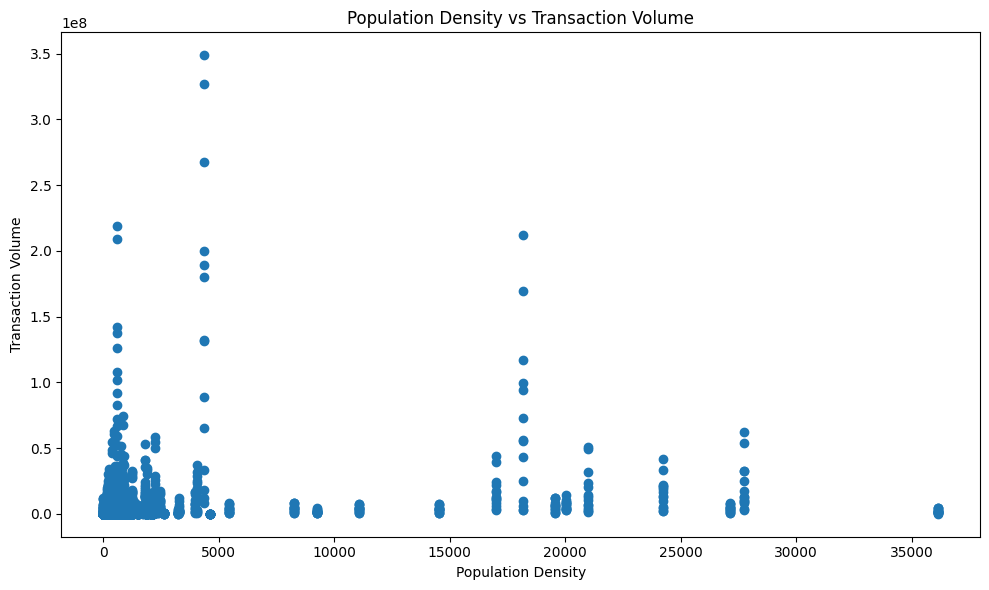

In [72]:
plt.figure(figsize=(10, 6))

plt.scatter(
    district_merge["Density"],
    district_merge["Transactions"]
)

plt.xlabel("Population Density")
plt.ylabel("Transaction Volume")
plt.title("Population Density vs Transaction Volume")

plt.tight_layout()
plt.show()

## 4.3: Average transaction amount per user

### 1.⁠ ⁠Merge relevant datasets to calculate the average transaction amount per user for each state. Display the results in a tabular format.

In [73]:
state_txn_and_users["Amount_Per_User"] = (state_txn_and_users["Amount (INR)"]/state_txn_and_users["Registered Users"])

In [74]:
average_Amount_per_user = state_txn_and_users.groupby("State")["Amount_Per_User"].mean().reset_index()

In [75]:
average_Amount_per_user

,State,Amount_Per_User
0,Andaman & Nicobar Islands,6846.811194
1,Andhra Pradesh,17502.277427
2,Arunachal Pradesh,9868.093852
3,Assam,8499.768302
4,Bihar,11287.137833
5,Chandigarh,12860.471685
6,Chhattisgarh,9215.205433
7,Dadra & Nagar Haveli and Daman & Diu,6168.978161
8,Delhi,14791.885162
9,Goa,7746.679818


### 2.⁠ ⁠Identify the top 5 states with the highest average transaction amount per user and the top 5 states with the lowest average transaction amount per user. Display the results.

In [76]:
top_5 = (average_Amount_per_user.sort_values("Amount_Per_User", ascending=False).head(5))

bottom_5 = (average_Amount_per_user.sort_values("Amount_Per_User", ascending=True).head(5))

print("Top 5 States:")
display(top_5)

print("Bottom 5 States:")
display(bottom_5)

Top 5 States:


,State,Amount_Per_User
31,Telangana,23774.041127
1,Andhra Pradesh,17502.277427
15,Karnataka,17318.863969
8,Delhi,14791.885162
28,Rajasthan,13708.117474


Bottom 5 States:


,State,Amount_Per_User
32,Tripura,4956.287167
18,Lakshadweep,5492.605845
16,Kerala,6038.016882
7,Dadra & Nagar Haveli and Daman & Diu,6168.978161
12,Himachal Pradesh,6373.195303


## 4.4: Device brand usage ratio

### 1.⁠ ⁠Merge the State_DeviceData dataset with the State_Txn and Users dataset.

In [77]:
device_merge = state_devicedata.merge(state_txn_and_users,on=["State", "Year", "Quarter"],how="left",suffixes=("_Device", "_State"))

In [78]:
device_merge.head()

,State,Year,Quarter,Brand,Registered Users_Device,Percentage,Transactions,Amount (INR),ATV (INR),Registered Users_State,App Opens,Amount_Per_User
0,Andaman & Nicobar Islands,2018,1,Xiaomi,1665,0.247033,6658,1.463176e+07,2197.621091,6740,0,2170.884454
1,Andaman & Nicobar Islands,2018,1,Samsung,1445,0.214392,6658,1.463176e+07,2197.621091,6740,0,2170.884454
2,Andaman & Nicobar Islands,2018,1,Vivo,982,0.145697,6658,1.463176e+07,2197.621091,6740,0,2170.884454
3,Andaman & Nicobar Islands,2018,1,Oppo,501,0.074332,6658,1.463176e+07,2197.621091,6740,0,2170.884454
4,Andaman & Nicobar Islands,2018,1,OnePlus,332,0.049258,6658,1.463176e+07,2197.621091,6740,0,2170.884454


### 2.⁠ ⁠Calculate the ratio of users using each device brand to the total number of registered users in each state. Display the results in a tabular format.

In [79]:
device_merge["Device_Usage_Ratio"] = (device_merge["Registered Users_Device"]/device_merge["Registered Users_State"])*100

In [80]:
device_merge.head()

,State,Year,Quarter,Brand,Registered Users_Device,Percentage,Transactions,Amount (INR),ATV (INR),Registered Users_State,App Opens,Amount_Per_User,Device_Usage_Ratio
0,Andaman & Nicobar Islands,2018,1,Xiaomi,1665,0.247033,6658,1.463176e+07,2197.621091,6740,0,2170.884454,24.703264
1,Andaman & Nicobar Islands,2018,1,Samsung,1445,0.214392,6658,1.463176e+07,2197.621091,6740,0,2170.884454,21.439169
2,Andaman & Nicobar Islands,2018,1,Vivo,982,0.145697,6658,1.463176e+07,2197.621091,6740,0,2170.884454,14.569733
3,Andaman & Nicobar Islands,2018,1,Oppo,501,0.074332,6658,1.463176e+07,2197.621091,6740,0,2170.884454,7.433234
4,Andaman & Nicobar Islands,2018,1,OnePlus,332,0.049258,6658,1.463176e+07,2197.621091,6740,0,2170.884454,4.925816


### 3.⁠ ⁠Create a bar chart depicting the device brand usage ratio for each state.

In [81]:
latest_device_data = device_merge[(device_merge["Year"] == latest_year) &(device_merge["Quarter"] == latest_quarter)]

In [82]:
device_ratio = latest_device_data.pivot(index = "State",columns = "Brand",values ="Device_Usage_Ratio")

In [83]:
device_ratio.head()

Brand,Apple,Asus,Gionee,HMD Global,Huawei,Infinix,Lava,Lenovo,Micromax,Motorola,OnePlus,Oppo,Others,Realme,Samsung,Tecno,Vivo,Xiaomi
State,,,,,,,,,,,,,,,,,,
Andaman & Nicobar Islands,1.856832,NaN,NaN,NaN,2.510669,NaN,NaN,NaN,NaN,1.697399,3.190273,8.786537,7.350028,6.496497,18.481359,1.568564,24.246719,23.815122
Andhra Pradesh,2.296984,NaN,NaN,NaN,2.244157,NaN,NaN,1.331238,NaN,2.563959,2.012400,11.075111,6.482132,9.264629,19.358179,NaN,18.205786,25.165424
Arunachal Pradesh,1.870851,NaN,0.927664,NaN,0.889966,NaN,NaN,NaN,NaN,0.823810,0.969058,15.673093,5.423695,8.308694,18.889612,NaN,23.446255,22.777301
Assam,1.150715,1.254169,1.149388,NaN,1.436472,NaN,NaN,NaN,NaN,1.183863,NaN,13.918723,9.551110,9.920803,14.452776,NaN,20.843470,25.138510
Bihar,NaN,NaN,NaN,NaN,1.440055,1.420646,NaN,1.029593,NaN,1.430257,NaN,12.201554,7.657372,10.522054,19.296267,1.054973,15.438527,28.508702


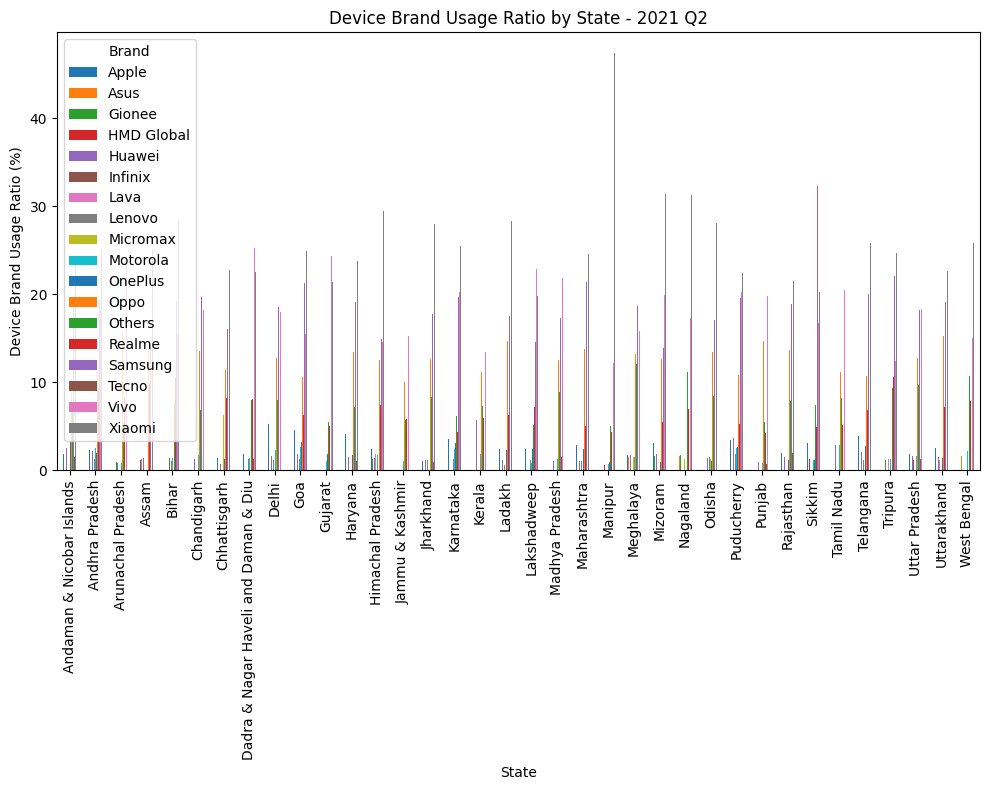

In [84]:
device_ratio.plot(kind = "bar",figsize = (10,8))
plt.xlabel("State")
plt.ylabel("Device Brand Usage Ratio (%)")
plt.title("Device Brand Usage Ratio by State - 2021 Q2")

plt.xticks(rotation=90)
plt.legend(title="Brand")

plt.tight_layout()
plt.show()

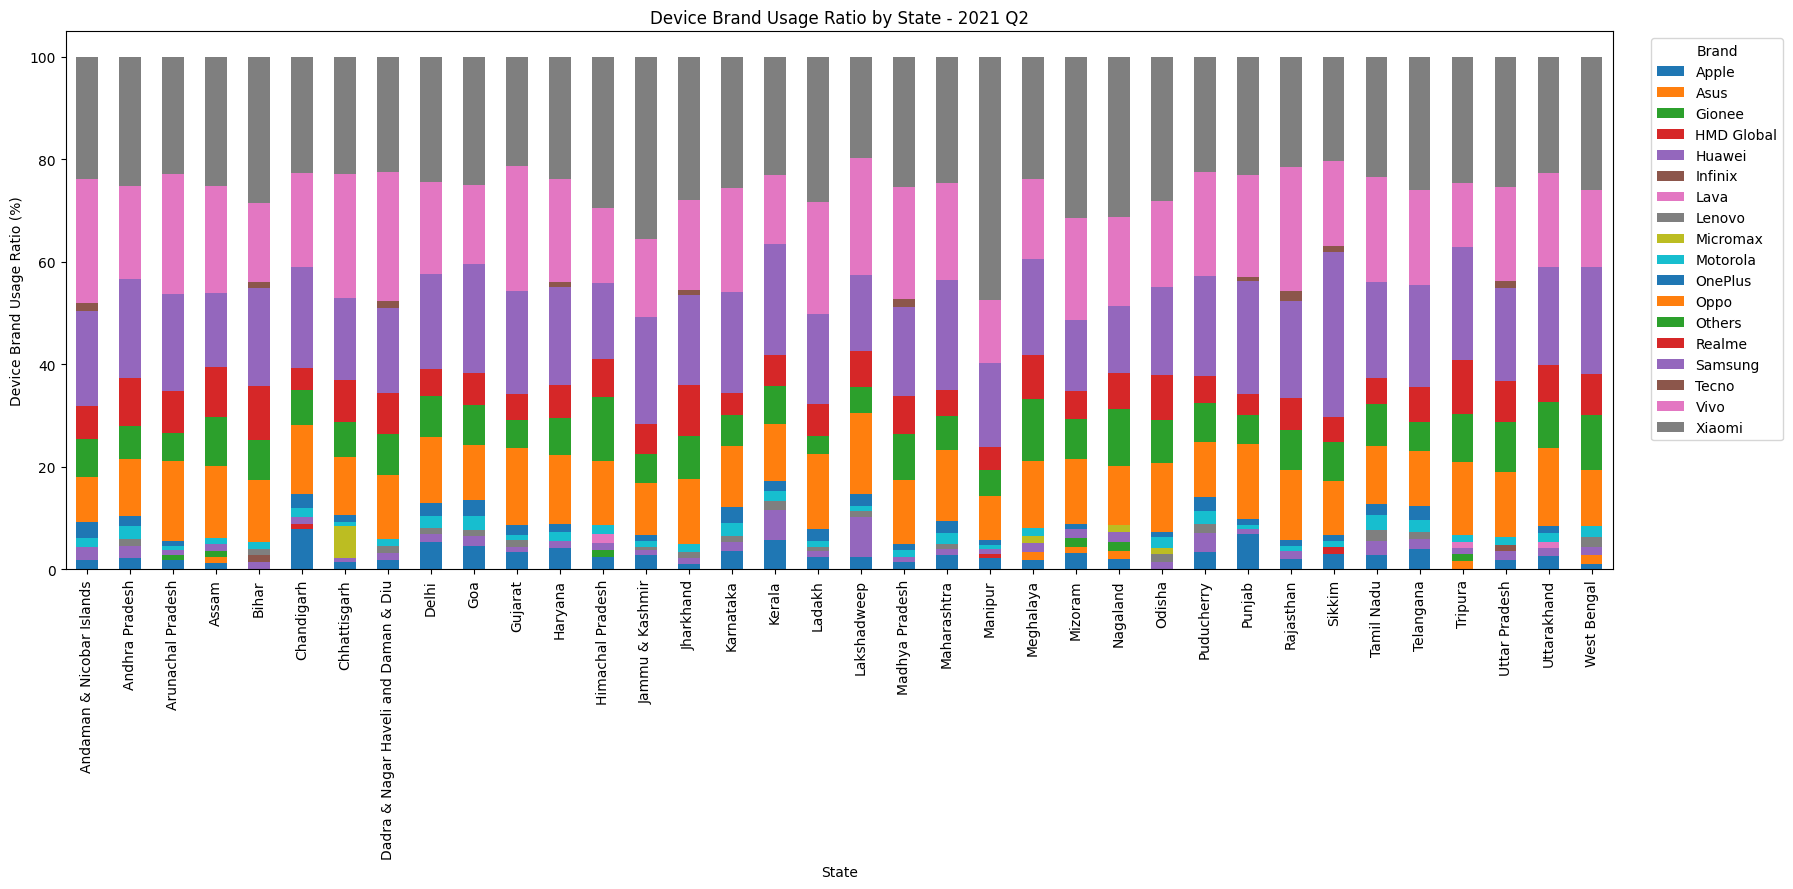

In [85]:
device_ratio = (
    latest_device_data
    .pivot(
        index="State",
        columns="Brand",
        values="Device_Usage_Ratio"
    )
)

ax = device_ratio.plot(
    kind="bar",
    stacked=True,
    figsize=(18, 9)
)

plt.xlabel("State")
plt.ylabel("Device Brand Usage Ratio (%)")
plt.title("Device Brand Usage Ratio by State - 2021 Q2")

plt.xticks(rotation=90)

plt.legend(
    title="Brand",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

# Task 5: Data Visualization

## 5.1: Plot the total transactions and amount over time for a selected state


### 1.⁠ ⁠Create a line plot showing the total number of transactions and the total transaction amount over time (years and quarters) for a selected state.

In [86]:
selected_state = "Gujarat"
gujarat_data = state_txn_and_users[state_txn_and_users["State"] == selected_state].copy()

In [87]:
gujarat_data = gujarat_data.sort_values(["Year", "Quarter"])

In [88]:
gujarat_data["Time"] = gujarat_data["Year"].astype(str)+" Q"+gujarat_data["Quarter"].astype(str)

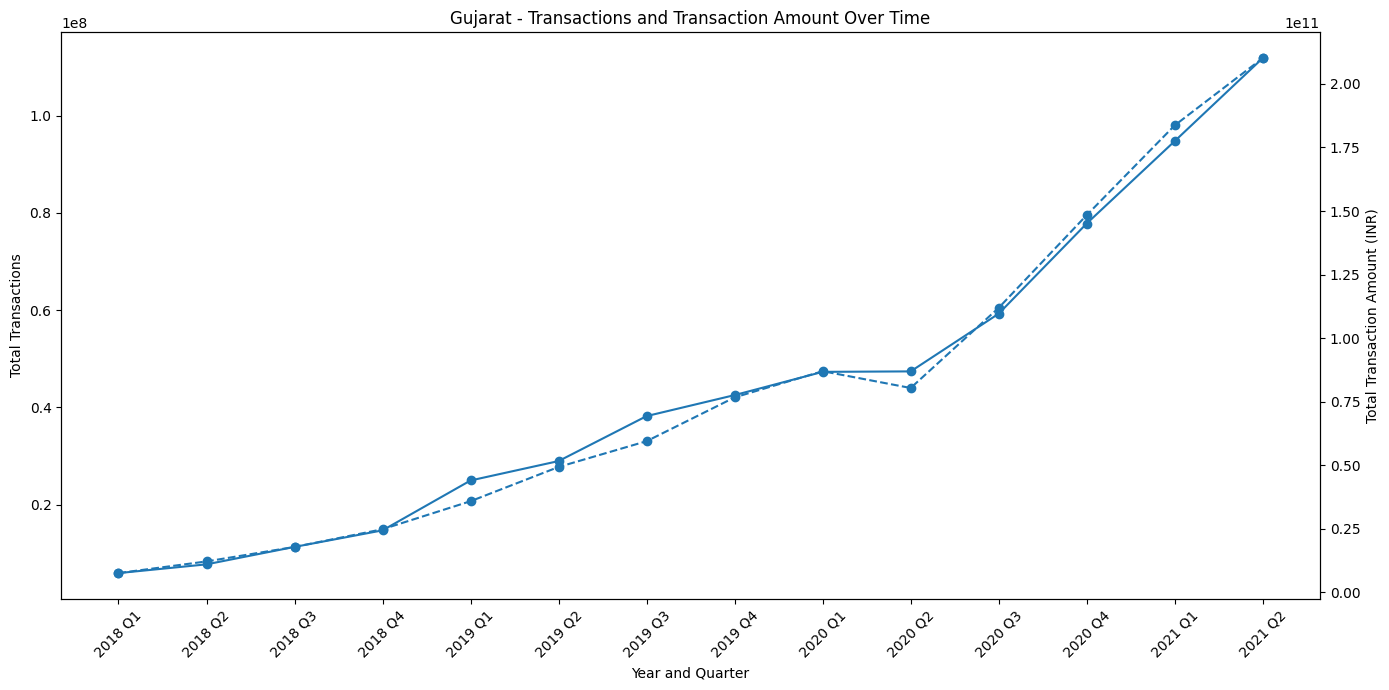

In [89]:
fig, ax1 = plt.subplots(figsize=(14, 7))

# Transactions
ax1.plot(
    gujarat_data["Time"],
    gujarat_data["Transactions"],
    marker="o",
    label="Total Transactions"
)

ax1.set_xlabel("Year and Quarter")
ax1.set_ylabel("Total Transactions")

# Transaction Amount
ax2 = ax1.twinx()

ax2.plot(
    gujarat_data["Time"],
    gujarat_data["Amount (INR)"],
    marker="o",
    linestyle="--",
    label="Total Transaction Amount"
)

ax2.set_ylabel("Total Transaction Amount (INR)")

plt.title("Gujarat - Transactions and Transaction Amount Over Time")

ax1.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 5.3: Visualize the population density of districts in a selected state

### 1.⁠ ⁠Create a bar plot showing the population density of districts in a selected state.

In [90]:
selected_state = "Gujarat"
gujarat_density = district_demographics[district_demographics["State"]==selected_state].copy()

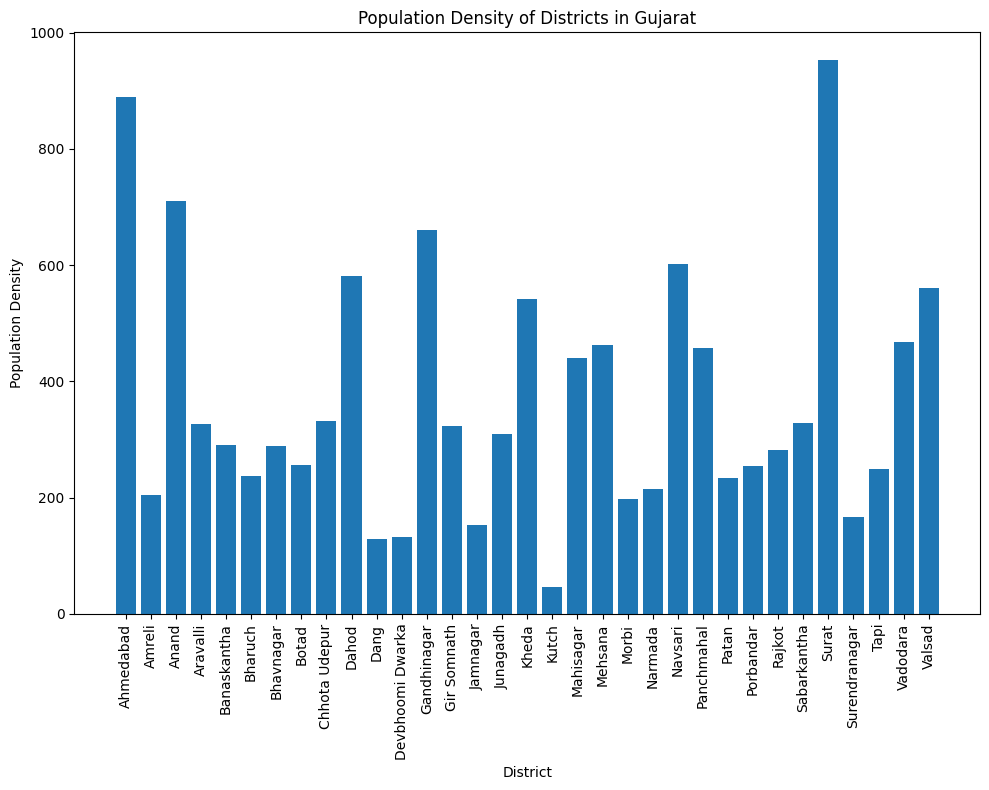

In [91]:
plt.figure(figsize = (10,8))
plt.bar(gujarat_density["District"],
       gujarat_density["Density"])

plt.xlabel("District")
plt.ylabel("Population Density")
plt.title("Population Density of Districts in Gujarat")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

# Task 6: Insights and Conclusions [Advanced Section]

## 6.1: Identify any trends or patterns in the transaction data

### 1.⁠ ⁠Analyze the transaction data to identify any noticeable trends or patterns.

In [92]:
transaction_trend = (
    state_txn_and_users
    .groupby(["Year", "Quarter"])[
        ["Transactions", "Amount (INR)"]
    ]
    .sum()
    .reset_index()
    .sort_values(["Year", "Quarter"])
)

transaction_trend["Period"] = (
    transaction_trend["Year"].astype(str)
    + " Q"
    + transaction_trend["Quarter"].astype(str)
)

In [93]:
transaction_trend

,Year,Quarter,Transactions,Amount (INR),Period
0,2018,1,134425599,1.718334e+11,2018 Q1
1,2018,2,187365440,3.043742e+11,2018 Q2
2,2018,3,341299764,4.751015e+11,2018 Q3
3,2018,4,417111607,6.717362e+11,2018 Q4
4,2019,1,708992981,9.900214e+11,2019 Q1
5,2019,2,815380896,1.354214e+12,2019 Q2
6,2019,3,1095009675,1.672559e+12,2019 Q3
7,2019,4,1460443663,2.259894e+12,2019 Q4
8,2020,1,1623038046,2.697112e+12,2020 Q1
9,2020,2,1448608890,2.646145e+12,2020 Q2


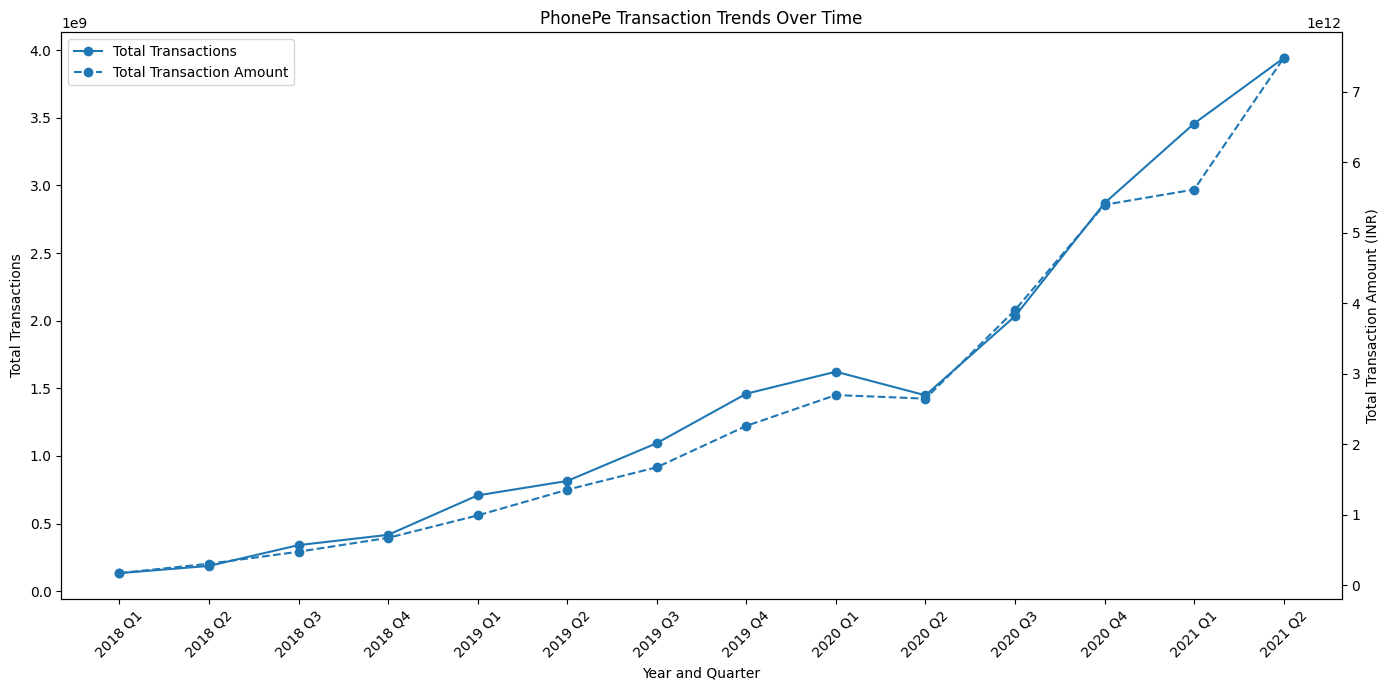

In [94]:
fig, ax1 = plt.subplots(figsize=(14, 7))

# Transactions
ax1.plot(
    transaction_trend["Period"],
    transaction_trend["Transactions"],
    marker="o",
    label="Total Transactions"
)

ax1.set_xlabel("Year and Quarter")
ax1.set_ylabel("Total Transactions")
ax1.tick_params(axis="x", rotation=45)

# Transaction amount
ax2 = ax1.twinx()

ax2.plot(
    transaction_trend["Period"],
    transaction_trend["Amount (INR)"],
    marker="o",
    linestyle="--",
    label="Total Transaction Amount"
)

ax2.set_ylabel("Total Transaction Amount (INR)")

plt.title("PhonePe Transaction Trends Over Time")

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper left"
)

plt.tight_layout()
plt.show()

## 6.2: Correlate demographic data with transaction data

### 1.⁠ ⁠Find correlations between demographic data (e.g, population density) and transaction data (e.g., transaction volume). Summarize your findings. 

In [95]:
correlation = district_merge[
    ["Population", "Area (sq km)", "Density",
     "Transactions", "Amount (INR)"]
].corr()

display(correlation)

,Population,Area (sq km),Density,Transactions,Amount (INR)
Population,1.000000,0.242551,0.220427,0.356491,0.364699
Area (sq km),0.242551,1.000000,-0.175262,0.055498,0.069442
Density,0.220427,-0.175262,1.000000,0.190389,0.212911
Transactions,0.356491,0.055498,0.190389,1.000000,0.974356
Amount (INR),0.364699,0.069442,0.212911,0.974356,1.000000


## 6.3: Summarize findings and insights

### 1.⁠ ⁠Summarize the key findings and insights from your analysis. Provide actionable recommendations based on the data. 

In [96]:
# Task 6.3: Summarize findings and insights

# Calculate a few portfolio-level metrics used in the summary.
total_txn = state_txn_and_users["Transactions"].sum()
top5_states = (
    state_txn_and_users.groupby("State")["Transactions"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)
top5_share = top5_states.sum() / total_txn * 100

corr = district_merge[["Population", "Area (sq km)", "Density", "Transactions"]].corr()["Transactions"]

latest_year = state_txn_and_users["Year"].max()
latest_quarter = state_txn_and_users.loc[
    state_txn_and_users["Year"].eq(latest_year), "Quarter"
].max()

print("KEY FINDINGS")
print("------------")
print(f"1. The dataset covers {state_txn_and_users['Year'].min()} to {latest_year}, across quarterly observations.")
print(f"2. The five states with the highest cumulative transaction volumes account for approximately {top5_share:.1f}% of all state-level transactions in the dataset.")
print(f"3. The state with the highest cumulative transaction volume is {top5_states.index[0]}.")
print(f"4. Population has a correlation of {corr['Population']:.2f} with district-level transaction volume.")
print(f"5. Population density has a correlation of {corr['Density']:.2f} with district-level transaction volume.")
print(f"6. Area has a correlation of {corr['Area (sq km)']:.2f} with district-level transaction volume.")
print(f"7. The latest period in the dataset is {latest_year} Q{latest_quarter}.")

print("\nACTIONABLE BUSINESS OBSERVATIONS")
print("--------------------------------")
print("• Use state-level transaction and app-open trends to identify markets with sustained digital-payment growth.")
print("• Combine transaction activity with demographic variables when evaluating district-level market opportunities.")
print("• Track device-brand usage alongside registered users to understand device concentration by state.")
print("• Reconcile district and state totals before using the data for reporting or decision-making.")


KEY FINDINGS
------------
1. The dataset covers 2018 to 2021, across quarterly observations.
2. The five states with the highest cumulative transaction volumes account for approximately 55.2% of all state-level transactions in the dataset.
3. The state with the highest cumulative transaction volume is Karnataka.
4. Population has a correlation of 0.36 with district-level transaction volume.
5. Population density has a correlation of 0.19 with district-level transaction volume.
6. Area has a correlation of 0.06 with district-level transaction volume.
7. The latest period in the dataset is 2021 Q2.

ACTIONABLE BUSINESS OBSERVATIONS
--------------------------------
• Use state-level transaction and app-open trends to identify markets with sustained digital-payment growth.
• Combine transaction activity with demographic variables when evaluating district-level market opportunities.
• Track device-brand usage alongside registered users to understand device concentration by state.
• Reconcil